# MESSIDOR × MAPLES-DR — Dataset Stratification and Splitting
**Objective:** Divide the processed dataset into Training, Validation, and Testing sets while strictly maintaining the distribution of rare target classes.  
**Key Features:**
1. **Multi-label Stratification:** Groups images by combining the binary presence of all target classes to ensure an equal disease distribution across splits.
2. **Rare Class Isolation:** Isolates unique combinations (groups containing only 1 sample) and forcefully assigns them to the Training set to prevent model blindness to rare lesions.
3. **Data Splitting Strategy:** Splits the remaining normal images into **70% Train**, **15% Validation**, and **15% Testing**.
4. **Data Reference Exports:** Exports `.csv` files (`train_split.csv`, `val_split.csv`, `test_split.csv`) containing the `Image_ID` references, avoiding unnecessary duplication of heavy image files.

In [7]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
### Step 0: Initialization & Identify Rare Classes
We combine the binary presence of all `TARGET_CLASSES` into a single string to form a unique `stratify_key`. Since `train_test_split` requires at least 2 samples per group, we isolate the "rare" combinations (groups with only 1 image) to send them directly to the Train set later.

- Import Lib

In [8]:
import os
import pandas as pd
import numpy as np
import cv2
import tqdm 
from pathlib import Path 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

- Define Path & Constants

In [22]:
base_dir = Path.cwd()
processed_dir = os.path.join(base_dir, 'Processed_Data')
x_dir = os.path.join(processed_dir,'images')
y_dir = os.path.join(processed_dir,'mask_multichannel')

# Original Masks path
col_masks = os.path.join(base_dir, 'MAPLES_Matched','masks')

# Doc Path
doc_dir = os.path.join(base_dir,'ForDocumentation')

- Target Classes

In [10]:
target_classes = ['OpticDisc', 'Macula', 'Exudates', 'Hemorrhages', 'Drusens']

- Generate df_occ from Processed Data

In [11]:
print("Scanning processed masks to generate occurrence DataFrame (df_occ)...")
processed_masks = [f for f in os.listdir(y_dir) if f.endswith('.npy')]
occ_data = []
for f in tqdm.tqdm(processed_masks, desc="Extracting Presence"):
    img_id = os.path.splitext(f)[0]
    mask_path = os.path.join(y_dir, f)
    
    # Load multi-channel mask (512, 512, 6)
    m = np.load(mask_path)
    
    # Check binary presence for each class (1 = present, 0 = absent)
    row = {"Image_ID": img_id}
    for i, cls in enumerate(target_classes):
        row[cls] = 1 if np.sum(m[:, :, i]) > 0 else 0
        
    occ_data.append(row)
# สร้างเป็นตาราง df_occ พร้อมใช้งาน
df_occ = pd.DataFrame(occ_data)
print(f"\nSuccessfully generated df_occ with {len(df_occ)} images.")
display(df_occ.head())

Scanning processed masks to generate occurrence DataFrame (df_occ)...


Extracting Presence: 100%|██████████| 198/198 [00:00<00:00, 417.96it/s]


Successfully generated df_occ with 198 images.


,Image_ID,OpticDisc,Macula,Exudates,Hemorrhages,Drusens
0,20051019_38557_0100_PP,1,1,1,1,1
1,20051020_44923_0100_PP,1,1,1,0,1
2,20051020_55346_0100_PP,1,0,1,1,0
3,20051020_55701_0100_PP,1,1,0,0,0
4,20051020_57566_0100_PP,1,1,1,1,0


- Isolate rare images vs normal images

In [12]:

print("1. Identifying rare combinations for Stratified Split...")
# Create a grouping key by concatenating binary labels (e.g., "10110")
df_occ['stratify_key'] = df_occ[target_classes].astype(str).agg(''.join, axis=1)
# Count occurrences of each key
key_counts = df_occ['stratify_key'].value_counts()
# Identify rare keys (only 1 image available)
rare_keys = key_counts[key_counts < 2].index
# Isolate rare images vs normal images
rare_df = df_occ[df_occ['stratify_key'].isin(rare_keys)].copy()
normal_df = df_occ[~df_occ['stratify_key'].isin(rare_keys)].copy()
print(f"-> Isolated {len(rare_df)} rare combination images (Will be assigned to Train Set).")
print(f"-> Remaining normal images for splitting: {len(normal_df)}")

1. Identifying rare combinations for Stratified Split...
-> Isolated 1 rare combination images (Will be assigned to Train Set).
-> Remaining normal images for splitting: 197


---
### Step 1: Multi-label Stratified Splitting
We split the "normal" (≥2 samples) groups into Train (70%), Validation (15%), and Test (15%). If any groups drop to only 1 sample during the first split, we isolate them again to prevent errors in the second split.

1. First split (Train 70% / Temp 30%)

In [13]:
print("Splitting normal images (70% Train / 30% Temp)...")
train_normal, temp_df = train_test_split(
    normal_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=normal_df['stratify_key']
)

Splitting normal images (70% Train / 30% Temp)...


2. Check if any group inside temp_df was reduced to only 1 image

In [14]:
temp_counts = temp_df['stratify_key'].value_counts()
rare_in_temp = temp_counts[temp_counts < 2].index

3. Isolate these new rare images

In [15]:
rare_temp_df = temp_df[temp_df['stratify_key'].isin(rare_in_temp)].copy()
normal_temp_df = temp_df[~temp_df['stratify_key'].isin(rare_in_temp)].copy()

print(f"-> Isolated {len(rare_temp_df)} rare images from the Temp set (Will be assigned to Train Set).")

-> Isolated 0 rare images from the Temp set (Will be assigned to Train Set).


4. Second split (Val 15% / Test 15%)

In [16]:
print("Splitting remaining Temp images (15% Val / 15% Test)...")
val_df, test_df = train_test_split(
    normal_temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=normal_temp_df['stratify_key']
)

Splitting remaining Temp images (15% Val / 15% Test)...


--- 
### Step 3: Recombine & Export Splits
We merge the normal Train set with all isolated rare images to form the final Training dataset. Finally, we save the splits as CSV files and verify the class distributions.

1. Combine normal train set with all rare images

In [17]:
train_df = pd.concat([train_normal, rare_df, rare_temp_df], ignore_index=True)
print("\n--- Data Split Summary ---")
print(f"Train set: {len(train_df)} images ({len(train_df)/len(df_occ):.1%})")
print(f"Val set:   {len(val_df)} images ({len(val_df)/len(df_occ):.1%})")
print(f"Test set:  {len(test_df)} images ({len(test_df)/len(df_occ):.1%})")


--- Data Split Summary ---
Train set: 138 images (69.7%)
Val set:   30 images (15.2%)
Test set:  30 images (15.2%)


2. Export to CSV

In [18]:
train_df.to_csv(os.path.join(processed_dir, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(processed_dir, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(processed_dir, "test_split.csv"), index=False)

3. Display disease distribution across splits

In [19]:
summary = pd.DataFrame({
    'Train': train_df[target_classes].sum(),
    'Val': val_df[target_classes].sum(),
    'Test': test_df[target_classes].sum()
})
display(summary)
print("\n✅ Stratification complete! Data splits successfully saved.")

,Train,Val,Test
OpticDisc,138,30,30
Macula,137,30,30
Exudates,73,16,15
Hemorrhages,85,19,18
Drusens,62,14,14



✅ Stratification complete! Data splits successfully saved.


---
### Step 4: Debugging (Find a Specific Rare Image)
Identify the exact `Image_ID` of an image that has a unique combination of lesions (e.g., missing a Macula mask but having Exudates and Hemorrhages).

In [20]:
# Example: Find a rare image with specific attributes
rare_img = df_occ[(df_occ['OpticDisc'] == 1) & 
                  (df_occ['Macula'] == 0) & 
                  (df_occ['Exudates'] == 1) & 
                  (df_occ['Hemorrhages'] == 1) & 
                  (df_occ['Drusens'] == 0)]

if not rare_img.empty:
    target_id = rare_img['Image_ID'].values[0]
    print(f"Identified Rare Image_ID: {target_id}")
else:
    # Fallback to a hardcoded ID if the specific condition isn't met
    target_id = "20051020_55346_0100_PP"
    print(f"No match found. Using default Image_ID: {target_id}")

Identified Rare Image_ID: 20051020_55346_0100_PP


---
### Step 5: Visual Sanity Check
Load the preprocessed image of the rare case and overlay its corresponding masks. We manually replicate the padding logic from Step 3 to ensure the original raw masks align perfectly with the `512x512` image.

1. Fetch the processed image (512x512)

Saved sanity check image to: d:\Backup\Senior-Project\Pre-Train\ForDocumentation\Rare_Case_Sanity_Check_20051020_55346_0100_PP.png


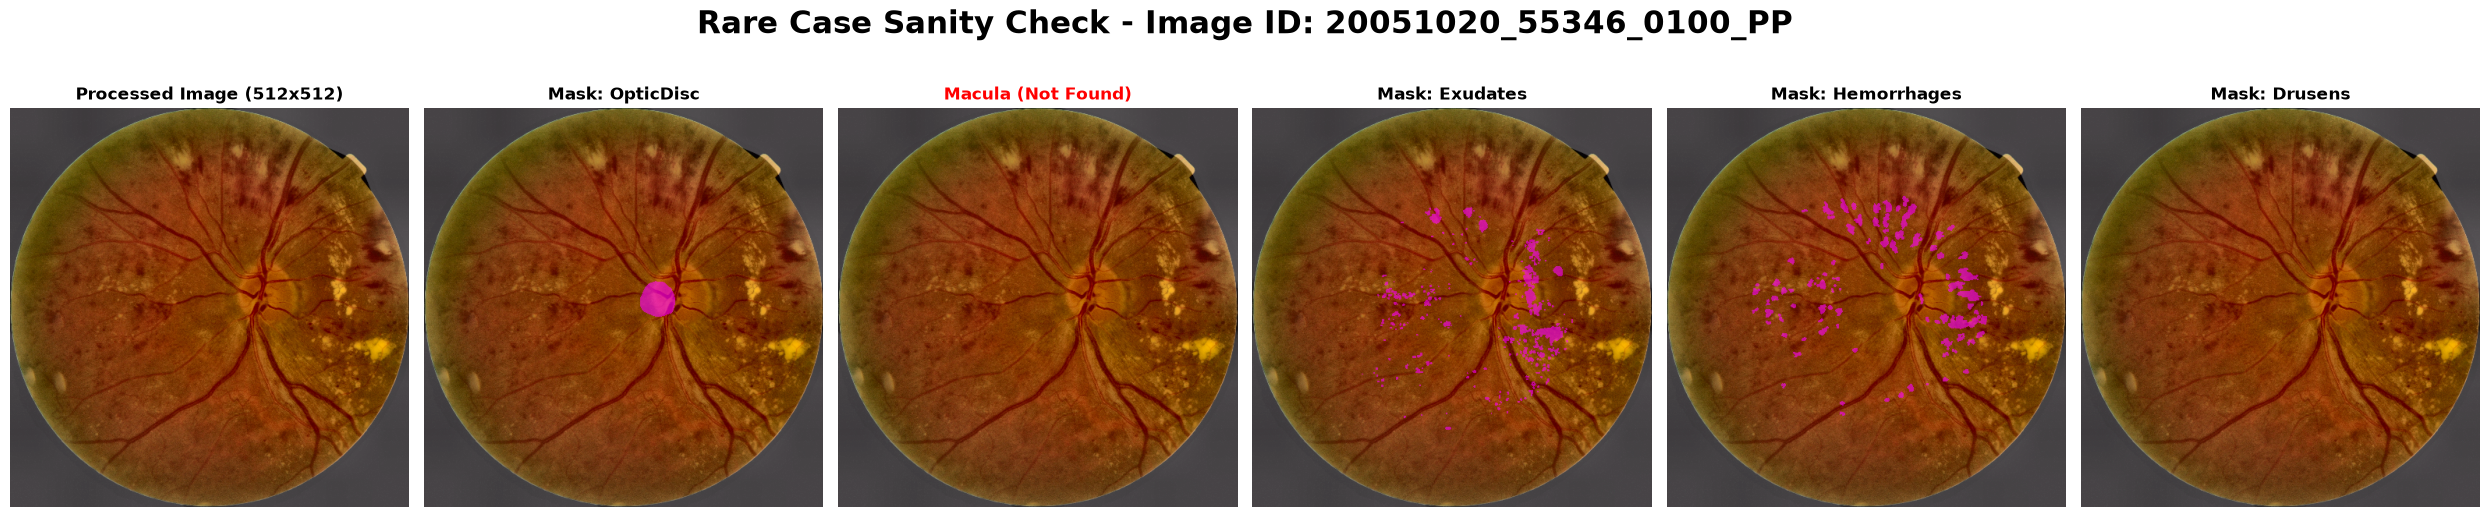

In [23]:
# Fetch the processed image (512x512)
img_path = os.path.join(x_dir, f"{target_id}.png")
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 6, figsize=(25, 5))
axes[0].imshow(image)
axes[0].set_title("Processed Image (512x512)", fontweight="bold")
axes[0].axis("off")

# Padding calculations (Assuming original resolution: 1488x2240)
# Make sure these variables match the image properties in your dataset
h, w = 1488, 2240 
max_side = max(h, w)
pad_h = (max_side - h) // 2
pad_w = (max_side - w) // 2

for i, cls in enumerate(target_classes):
    mask_path = os.path.join(col_masks, cls, f"{target_id}.png")
    
    if os.path.exists(mask_path):
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Apply padding exactly like in the preprocessing step
        m_padded = cv2.copyMakeBorder(m, pad_h, (max_side - h) - pad_h, 
                                      pad_w, (max_side - w) - pad_w, 
                                      cv2.BORDER_CONSTANT, value=0)
        
        # Resize using Nearest Neighbor interpolation
        m_resized = cv2.resize(m_padded, (512, 512), interpolation=cv2.INTER_NEAREST)
        
        axes[i+1].imshow(image)
        # Overlay mask using masked array
        overlay = np.ma.masked_where(m_resized == 0, m_resized)
        axes[i+1].imshow(overlay, alpha=0.6, cmap='spring')
        axes[i+1].set_title(f"Mask: {cls}", fontweight="bold")
    else:
        axes[i+1].imshow(image)
        axes[i+1].set_title(f"{cls} (Not Found)", color='red', fontweight="bold")
        
    axes[i+1].axis("off")

plt.suptitle(f"Rare Case Sanity Check - Image ID: {target_id}", fontsize=22, fontweight="bold", y=1.05)
plt.tight_layout()

os.makedirs(doc_dir, exist_ok=True)
fig_path = os.path.join(doc_dir, f'Rare_Case_Sanity_Check_{target_id}.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved sanity check image to: {fig_path}")

plt.show()

---
### Step 6: Export for Kaggle (Zip Dataset)
To facilitate easy uploading to cloud platforms like Kaggle or Google Colab, we compress the entire `Processed_Dataset` directory (which includes preprocessed images, multi-channel masks, and the split CSV files) into a single `.zip` archive.

In [24]:
import shutil

# Define file name Zip 
zip_name = os.path.join(base_dir, "MAPLES_DR_Preprocessed")

print(f"Compressing dataset to {zip_name}.zip ...")
print("This may take a few minutes depending on your disk speed. Please wait...")

# Zip the Processed_Data Folder 
shutil.make_archive(
    base_name=zip_name, 
    format='zip', 
    root_dir=processed_dir 
)

print(f"Compression complete! The dataset is ready to upload.")
print(f"File saved at: {zip_name}.zip")

Compressing dataset to d:\Backup\Senior-Project\Pre-Train\MAPLES_DR_Preprocessed.zip ...
This may take a few minutes depending on your disk speed. Please wait...
Compression complete! The dataset is ready to upload.
File saved at: d:\Backup\Senior-Project\Pre-Train\MAPLES_DR_Preprocessed.zip
